In [188]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
%precision 4

'%.4f'

## 1\. **Radioactive decay chain**

${\rm Tl}^{208}$ decays to ${\rm Pb}^{208}$ with a half-lieve of 3.052 minutes. Suppose to start with a sample of 1000 Thallium atoms and 0 of Lead atoms.

* Take steps in time of 1 second and at each time-step decide whether each Tl atom has decayed or not, accordingly to the probability $p(t)=1-2^{-t/\tau}$. Subtract the total number of Tl atoms that decayed at each step from the Tl sample and add them to the Lead one. Plot the evolution of the two sets as a function of time  

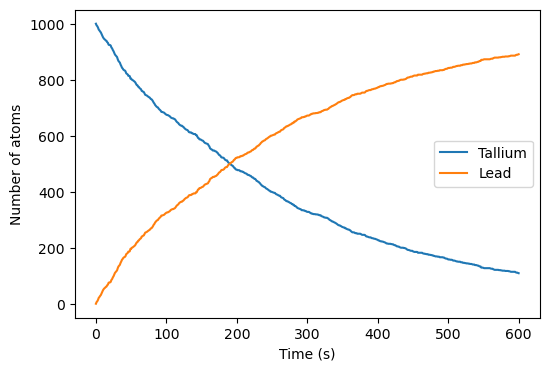

In [123]:
# IDEA: at each time step, we confront each atom decaiyng probability with a random number

tau = 3.052*60    # emilife in seconds
tl = [1000]       # number of tallium atoms in time
pb = [0]          # number of lead atoms in time
time_sim = 600    # simulation time in seconds

# let's run the algorithm: for each time step i check if each tallium is decayed
for i in range(time_sim): 
    temp = tl[-1]    # temporale variable
    for j in range(tl[-1]):
        x = npr.rand()
        if x <= 1-2**(-1/tau):   # confronted con prob of decaying in 1 second
            temp -= 1
    tl.append(temp)
    pb.append(1000-temp)

# plot:
plt.figure(figsize=(6,4))
plt.plot( range(time_sim+1), tl, label='Tallium')
plt.plot( range(time_sim+1), pb, label='Lead')
plt.xlabel("Time (s)")
plt.ylabel("Number of atoms")
plt.legend()

In [ ]:
# METHOD WITH ACCEPT-REJECT (MAYBE WRONG IDEA)

# we use reject-sampling with g(x) = 1/time_sim, M = time_sim, f(x) = p(x)
def acc_nega(tau, time_sim):
    x = npr.rand()*time_sim
    u = npr.rand()
    # f(x) / (M * g(x)) = f(x)
    if u <= 1-2**(-x/tau):
        acc_nega.tl -=1
        acc_nega.pb +=1

# definiamo gli attributi iniziali di acc_nega:
acc_nega.tl = 1000
acc_nega.pb = 0
tau = 3.052*60   # emilife in seconds
tl = []          # number of talliums in time
pb = []
time_sim = 50    # simulation time in seconds

# let's run the algorithm: for each time step i check if each tallium is decayed
for i in range(time_sim):          
    for j in range(acc_nega.tl):
        #print(acc_nega.tl)
        acc_nega(tau, time_sim)
    #print('finished a time step')
    tl.append( acc_nega.tl )
    pb.append( acc_nega.pb )
    #print(acc_nega.tl)
print("valori finali tallio e piombo:", acc_nega.tl, acc_nega.pb)

# plot:
plt.figure(figsize=(4,3))
plt.plot( list(range(time_sim)) , tl, 'o', markersize=3)
plt.plot( list(range(time_sim)) , pb, 'ro', markersize=3)

* Repeat the exercise by means of the inverse transform method: draw 1000 random numbers from the non-uniform probability distribution $p(t)=2^{-t/\tau}\frac{\ln 2}{\tau}$ to represent the times of decay of the 1000 Tl atoms. Make a plot showing the number of atoms that have not decayed as a function of time

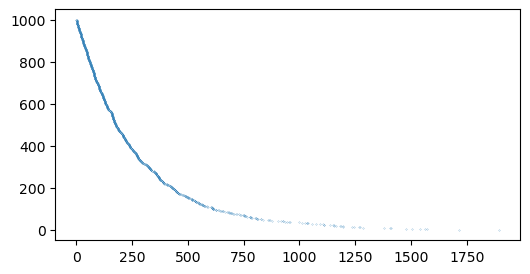

In [186]:
# NOTE: now p(t) is the probability of NOT decaying
# so the CDF is 1-2**(-t/tau), which have values in [0,1] as output
# the inverse CDF is: t = -tau*(np.log(1-u)/np.log(2)) 

u = npr.rand(1000)
t = -tau*(np.log(1-u)/np.log(2))    # times of decay!!
#plt.plot( range(1000, -1) )

# plot:
tl = np.arange(999, -1, -1)
t_ord = np.sort(t)
plt.figure(figsize=(6,3))
plt.plot(t_ord, tl, '.', markersize=0.3)
#plt.xlim(0,1000)

## 2\. **Rutherford Scattering**

The scattering angle $\theta$ of $\alpha$ particles hitting a positively charged nucleus of a Gold atom ($Z=79$) follows the rule:

$$
\tan{\frac{1}{2} \theta} = \frac{Z e^2} {2\pi \epsilon_0 E b}
$$

where $E=7.7$ MeV and $b$ beam is the impact parameter. The beam is represented by a 2D gaussian distribution with $\sigma=a_0/100$ for both coordinates ($a_0$ being the Bohr radius). Assume 1 million $\alpha$ particles are shot on the gold atom.

Computing the fraction of particles that "bounce back",i.e. those particle whose scattering angle is greater than $\pi/2$ (which set a condition on the impact parameter $b$)

limite per rimbalzo 2.9521145802062624e-14
frazione rimbalzata: 0.001627


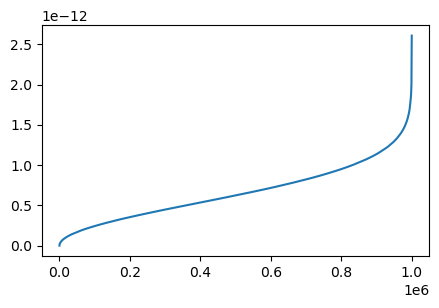

In [195]:
# IDEA: we use box-muller method to generate a sample of normally distributed variables in 2d

# initial values:
E = 7.7*1.6*10**(-19)*10**6    # energia in Joule
sigma = (0.53/100)*10**(-10)   # from angstrom to meters
N = 1000000                    # 1 million particles
e = 1.6*10**(-19)              # carica elettrone

# box-muller:
u = npr.rand(N)    # uniform random variables
u_ord = np.sort(u)
r = np.sqrt(-2*sigma**2*np.log(1-u_ord))    # radius values distributed like a gaussian
plt.figure(figsize=(5,3))
plt.plot(r)

# computing the fraction:
limit = (79*e**2)/(2*np.pi*8.85*10**(-12)*E)
print("limite per rimbalzo", limit)
print("frazione rimbalzata:", len(r[r<limit])/N )

## 3\. **Monte Carlo integration: hit/miss vs mean value method**

Consider the function:
$$f(x) =\sin^2{\frac{1}{x(2-x)}}$$
* Compute the integral of $f(x)$ between 0 and 2 with the hit/miss method. Evaluate the error of your estimate

In [282]:
# i think the result should be 1.4514
def f(x):
    return (np.sin(1/(2*x-x**2)))**2

# first we study the function to identify area A:
x = np.linspace(0.0001,1.999, 500)
y = f(x)
#plt.plot(x,y)

# monte carlo:
A = 2*1     # base*altezza, scelte guardando il grafico
N = 10**6  # number of random tests
k = 0       # counts
for i in range(N):
    x = npr.rand()*2
    y = npr.rand()
    if y < f(x): k+=1
I = k/N*A
print("risultato: ", I)

risultato:  1.451184


* Repeat the integral with the mean value method. Evaluate the error and compare it with the previous one

In [281]:
def f(x):
    return (np.sin(1/(2*x-x**2)))**2

N = 10**6        # number of tests
x = npr.rand(N)
I = (2-0)/N*np.sum(f(x))
print("risultato: ", I)

risultato:  1.4512544769394728


## 4\. **Monte Carlo integration in high dimension**

* Start of by computing the area of a circle of unit radius, by integrating the function 

$$
f(x,y)=
\left\{
\begin{array}{ll}
      1 & x^2+y^2\le 1 \\
      0 & {\rm elsewhere}
\end{array} 
\right.
$$

In [362]:
# PROBABILISTIC METHOD (hit/miss method):
# i have to calculate the volume of that cilinder of height 1
def f(x,y):
    if x**2 + y**2 <= 1:
        return 1
    else: return 0
        
A = 2*2*1    # parallelepipedo di volume 2x2x1
N = 10**5    # test da fare
k = 0        # counts
for i in range(N):
    x = npr.rand()
    y = npr.rand()
    if y < f(x,y): k+=1
I = k/N*A
print("hit/miss:", I)

hit/miss: 3.14188


In [361]:
# MEAN VALUE METHOD (maybe non-sense using it)
def f(rho):
    if rho <=1: return 1
    else: return 0

V = np.pi
N = 10**6
sample = npr.rand(N)
somma = np.array( [f(sample[i]) for i in range(N)] )
I = V/N*np.sum(somma)
print("mean value", I)

mean value 3.141592653589793


* Generalize the result for a 10D sphere

In [ ]:
# devo usare il volume di un'ipersfera? e con quale metodo?

## 5\. **Monte Carlo integration with importance sampling** 

Calculate the value of the integral:

$$
I=\int_0^1 \frac{x^{-1/2}}{e^x+1} dx
$$

using the importance sampling method with $w(x)=1/\sqrt{x}$. You should get a result about 0.83893